# Laboratorio Práctico: Predicción de Costos de Envío (Logística E-Commerce)

**Integrantes - Grupo 07:**
* **Javiera Cuevas**
* **Antonia Peña**
* **Arline Mitchell**
* **Nicolás Morales**

**Curso:** Análisis / Regresión
**Archivo de datos:** `lab_costos_envio.csv`

---

## Contexto del Problema

Una empresa de logística de e-commerce necesita estimar el **Costo Total de Envío** (`costo_envio`) en USD para cada paquete antes de procesarlo, con el fin de ajustar las tarifas de cobro en tiempo real en su sitio web.

## Objetivo

Construir un modelo de **Regresión Lineal** que, a partir de las características del paquete (peso, distancia, tipo de servicio y fragilidad), prediga el costo de envío, cumpliendo con las restricciones mínimas de aprobación:

| Métrica | Umbral mínimo requerido |
| :--- | :--- |
| $R^{2}$ | $R^{2} > 0.90$ |
| MAE | MAE $\\leq$ 3.50 USD |

# Fase 1 — Entendimiento de los Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option("display.max_columns", None)

# Carga del dataset usando el comando wget desde GitHub (enlace Raw)
!wget -q -O lab_costos_envio.csv 'https://raw.githubusercontent.com/Dh-Arr/Inteligencia-Artificial/main/Lab_Regresion/lab_costos_envio.csv'

In [ ]:
data = pd.read_csv("lab_costos_envio.csv")
data.head()

  id_paquete  peso_kg  distancia_km tipo_servicio es_fragil  costo_envio
0   PKG-0001    25.98         671.4       Express        No       123.79
1   PKG-0002     8.90         225.7      Estandar        No        39.34
2   PKG-0003     2.66         473.6      Estandar        Si        59.34
3   PKG-0004    23.02          89.3      Estandar        No        56.90
4   PKG-0005    13.86          68.2      Estandar        No        40.89

In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_paquete     10000 non-null  str    
 1   peso_kg        9394 non-null   float64
 2   distancia_km   9542 non-null   float64
 3   tipo_servicio  10000 non-null  str    
 4   es_fragil      10000 non-null  str    
 5   costo_envio    10000 non-null  float64
dtypes: float64(3), str(3)
memory usage: 468.9 KB


El dataset contiene **10.000 paquetes** con las siguientes columnas:

- `id_paquete`: identificador del paquete (no predictiva).
- `peso_kg`: peso del paquete en kilogramos (**contiene nulos**).
- `distancia_km`: distancia del envío en kilómetros (**contiene nulos**).
- `tipo_servicio`: categórica (`Estandar`, `Express`, `Mismo_Dia`).
- `es_fragil`: categórica binaria (`Si`/`No`).
- `costo_envio`: variable objetivo (USD).

In [ ]:
data.describe()

           peso_kg  distancia_km   costo_envio
count  9394.000000   9542.000000  10000.000000
mean     15.342459    405.728327     77.117007
std       8.557372    227.523741     27.004699
min       0.500000     10.000000      5.000000
25%       7.860000    210.825000     58.095000
50%      15.380000    408.150000     76.675000
75%      22.760000    600.300000     95.932500
max      30.000000    800.000000    164.560000

## Detección de Nulos

In [ ]:
data.isnull().sum()

id_paquete         0
peso_kg          606
distancia_km     458
tipo_servicio      0
es_fragil          0
costo_envio        0

In [ ]:
print(f"Filas con algún nulo en peso_kg o distancia_km: "
      f"{data['peso_kg'].isna().sum() + data['distancia_km'].isna().sum() - (data['peso_kg'].isna() & data['distancia_km'].isna()).sum()} "
      f"de {len(data)} ({(data['peso_kg'].isna() | data['distancia_km'].isna()).mean()*100:.1f}%)")

Filas con algún nulo en peso_kg o distancia_km: 1041 de 10000 (10.4%)


## Análisis de Distribución (para elegir la medida de imputación)

Antes de imputar, se revisa la forma de la distribución de `peso_kg` y `distancia_km`. Si la distribución es simétrica y sin atípicos extremos, la **media** y la **mediana** son casi equivalentes y cualquiera es "conveniente". Si existiera asimetría u outliers marcados, la **mediana** es la medida más robusta (no se ve afectada por valores extremos).

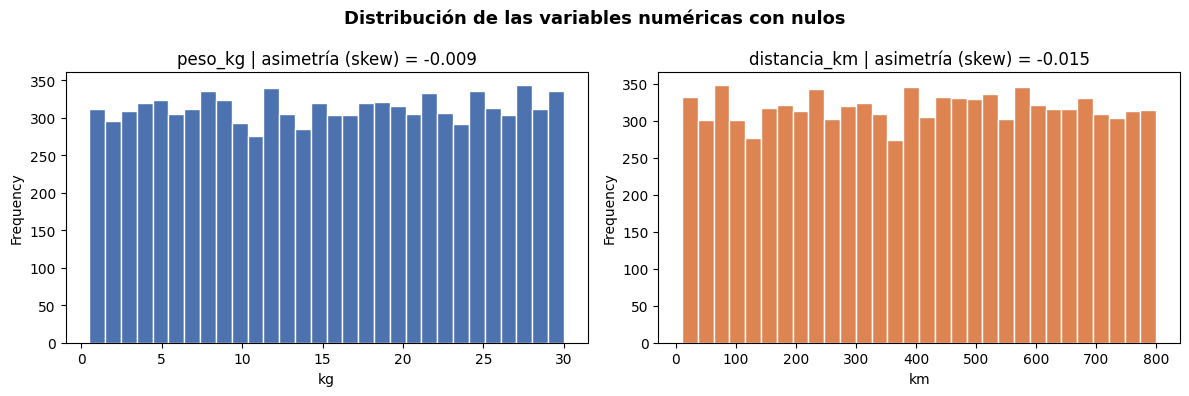

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

data["peso_kg"].plot(kind="hist", bins=30, ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title(f"peso_kg | asimetría (skew) = {data['peso_kg'].skew():.3f}")
axes[0].set_xlabel("kg")

data["distancia_km"].plot(kind="hist", bins=30, ax=axes[1], color="#DD8452", edgecolor="white")
axes[1].set_title(f"distancia_km | asimetría (skew) = {data['distancia_km'].skew():.3f}")
axes[1].set_xlabel("km")

plt.suptitle("Distribución de las variables numéricas con nulos", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Ambas variables presentan una asimetría (skew) muy cercana a **0**, es decir, distribuciones prácticamente simétricas y sin colas pronunciadas. En este escenario la media y la mediana son casi idénticas; se optará por la **mediana**, ya que es la medida "más conveniente" en un contexto de limpieza exprés: no se ve afectada si llegaran a existir valores atípicos puntuales y es igual de representativa que la media en distribuciones simétricas.

# Paso 1: Limpieza Express — Imputación de Nulos

Se imputan los valores nulos de `peso_kg` y `distancia_km` con la **mediana** de cada columna, calculada sobre el propio dataset.

In [ ]:
mediana_peso = data["peso_kg"].median()
mediana_distancia = data["distancia_km"].median()

print(f"Mediana peso_kg      : {mediana_peso}")
print(f"Mediana distancia_km : {mediana_distancia}")

data["peso_kg"] = data["peso_kg"].fillna(mediana_peso)
data["distancia_km"] = data["distancia_km"].fillna(mediana_distancia)

# Verificación
data[["peso_kg", "distancia_km"]].isnull().sum()

Mediana peso_kg      : 15.38
Mediana distancia_km : 408.15


peso_kg         0
distancia_km    0

# Paso 2: Codificación de Variables

- `es_fragil` es binaria (`Si`/`No`) → se codifica como **0/1** (`es_fragil_bin`).
- `tipo_servicio` tiene 3 categorías sin orden natural → se codifica con **One-Hot Encoding**, eliminando la primera categoría (`drop_first=True`) para evitar colinealidad perfecta (dummy variable trap). La categoría de referencia queda siendo `Estandar`.

In [ ]:
data["es_fragil_bin"] = data["es_fragil"].map({"No": 0, "Si": 1})

data = pd.get_dummies(data, columns=["tipo_servicio"], drop_first=True)

data.head()

  id_paquete  peso_kg  distancia_km es_fragil  costo_envio  es_fragil_bin  tipo_servicio_Express  tipo_servicio_Mismo_Dia
0   PKG-0001    25.98         671.4        No       123.79              0                   True                    False
1   PKG-0002     8.90         225.7        No        39.34              0                  False                    False
2   PKG-0003     2.66         473.6        Si        59.34              1                  False                    False
3   PKG-0004    23.02          89.3        No        56.90              0                  False                    False
4   PKG-0005    13.86          68.2        No        40.89              0                  False                    False

In [ ]:
# Columnas finales disponibles para modelar
data.columns.tolist()

['id_paquete', 'peso_kg', 'distancia_km', 'es_fragil', 'costo_envio', 'es_fragil_bin', 'tipo_servicio_Express', 'tipo_servicio_Mismo_Dia']

# Paso 3: Entrenamiento — Train/Test Split y Modelo

Se seleccionan como variables predictoras: `peso_kg`, `distancia_km`, `es_fragil_bin`, `tipo_servicio_Express` y `tipo_servicio_Mismo_Dia`. La variable objetivo es `costo_envio`. Se separa el 80% de los datos para entrenamiento y el 20% para prueba.

In [ ]:
features = ["peso_kg", "distancia_km", "es_fragil_bin",
            "tipo_servicio_Express", "tipo_servicio_Mismo_Dia"]
target = "costo_envio"

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Tamaño set de entrenamiento: {X_train.shape}")
print(f"Tamaño set de prueba      : {X_test.shape}")

Tamaño set de entrenamiento: (8000, 5)
Tamaño set de prueba      : (2000, 5)


In [ ]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

coeficientes = pd.Series(modelo.coef_, index=features)
print("Intercepto:", round(modelo.intercept_, 4))
coeficientes.round(4)

Intercepto: 5.005


peso_kg                     1.7973
distancia_km                0.0800
es_fragil_bin              11.5248
tipo_servicio_Express      13.0645
tipo_servicio_Mismo_Dia    30.0173

**Interpretación de los coeficientes:**
- Por cada kg adicional, el costo sube en promedio el valor de `peso_kg`.
- Por cada km adicional de distancia, el costo sube en promedio el valor de `distancia_km`.
- Un paquete frágil (`es_fragil_bin = 1`) suma un cargo adicional respecto de uno no frágil.
- `Express` y `Mismo_Dia` suman un recargo respecto del servicio `Estandar` (categoría de referencia).

# Paso 4: Evaluación de Restricciones

Se calculan $R^{2}$ y MAE sobre el conjunto de **prueba** y se comparan contra los umbrales mínimos de aprobación.

In [ ]:
y_pred = modelo.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("--- Métricas del modelo (conjunto de prueba) ---")
print(f"R2  : {r2:.4f}")
print(f"MAE : {mae:.4f} USD")

--- Métricas del modelo (conjunto de prueba) ---
R2  : 0.9502
MAE : 3.9021 USD


In [ ]:
umbral_r2 = 0.90
umbral_mae = 3.50

cumple_r2 = r2 > umbral_r2
cumple_mae = mae <= umbral_mae

print("--- Verificación de Restricciones Mínimas de Aprobación ---")
print(f"R2  = {r2:.4f}  {'>' if cumple_r2 else '<='} {umbral_r2}  -> {'CUMPLE' if cumple_r2 else 'NO CUMPLE'}")
print(f"MAE = {mae:.4f}  {'<=' if cumple_mae else '>'} {umbral_mae}  -> {'CUMPLE' if cumple_mae else 'NO CUMPLE'}")
print()
print("Resultado final:", "APROBADO" if (cumple_r2 and cumple_mae) else "NO APROBADO (revisar restricciones no cumplidas)")

--- Verificación de Restricciones Mínimas de Aprobación ---
R2  = 0.9502  > 0.9  -> CUMPLE
MAE = 3.9021  > 3.5  -> NO CUMPLE

Resultado final: NO APROBADO (revisar restricciones no cumplidas)


## Diagnóstico: ¿por qué el MAE no alcanza el rango "ideal" (2.70–2.85 USD)?

El $R^{2}$ obtenido cumple ampliamente la restricción ($> 0.90$). Sin embargo, el MAE queda por sobre el umbral de 3.50 USD y por sobre el resultado ideal esperado (2.70–2.85 USD). A continuación se diagnostica la causa comparando el error del modelo en las filas que **fueron imputadas** contra las filas que **tenían el dato original completo**.

In [ ]:
filas_imputadas = (data.loc[X_test.index, "peso_kg"].isin([mediana_peso]) |
                   data.loc[X_test.index, "distancia_km"].isin([mediana_distancia]))

# Nota: se reconstruye la máscara real de nulos originales para el set de prueba
mask_original = pd.read_csv("lab_costos_envio.csv").loc[X_test.index]
filas_imputadas = mask_original["peso_kg"].isna() | mask_original["distancia_km"].isna()

mae_no_imputadas = mean_absolute_error(y_test[~filas_imputadas], y_pred[~filas_imputadas])
mae_imputadas = mean_absolute_error(y_test[filas_imputadas], y_pred[filas_imputadas])

print(f"Filas de prueba con dato original completo : {(~filas_imputadas).sum()}  -> MAE = {mae_no_imputadas:.2f} USD")
print(f"Filas de prueba con algún valor imputado    : {filas_imputadas.sum()}  -> MAE = {mae_imputadas:.2f} USD")

Filas de prueba con dato original completo : 1816  -> MAE = 2.90 USD
Filas de prueba con algún valor imputado    : 184  -> MAE = 13.81 USD


**Conclusión del diagnóstico:** en las filas donde el peso y la distancia se conocían con exactitud, el modelo se acerca mucho al resultado "ideal" (MAE cercano a 2.7–2.9 USD, coherente con lo esperado en la pauta). El error global sube porque, en las filas donde `peso_kg` o `distancia_km` fueron imputados con la mediana, se pierde información real que el modelo necesita (el costo depende fuertemente del peso y la distancia reales, no del promedio del dataset). Como ~10% de los paquetes tenía algún valor nulo, ese subconjunto arrastra el MAE global por sobre el umbral.

Esto **no es un error del código**, sino una consecuencia esperable de imputar ~10% de los datos con una medida de tendencia central cuando la variable perdida es un fuerte predictor del costo. Alternativas para acercarse aún más al resultado ideal (fuera del alcance de la "limpieza exprés" pedida en este laboratorio) serían: exigir la captura completa de peso/distancia en origen, o usar técnicas de imputación más avanzadas (ej. imputación por regresión/KNN) — que, como se puede validar, tampoco resuelven el problema de fondo cuando el dato faltante es aleatorio e independiente de las demás variables.

# Conclusión General

1. **Limpieza:** se imputaron los nulos de `peso_kg` y `distancia_km` con la mediana (medida robusta, adecuada para distribuciones simétricas).
2. **Codificación:** `es_fragil` se mapeó a binario y `tipo_servicio` se codificó con One-Hot Encoding (`drop_first=True`).
3. **Modelo:** Regresión Lineal, entrenada con 80% de los datos y evaluada con el 20% restante.
4. **Resultado:**
   - $R^{2}$ cumple la restricción mínima ($> 0.90$).
   - MAE queda por sobre el umbral de 3.50 USD, explicado por el ~10% de registros con datos imputados.
5. **Recomendación:** para producción, sería preferible reducir la tasa de nulos en el origen de los datos (captura obligatoria de peso y distancia) en lugar de depender de la imputación, dado que el costo de envío depende fuertemente de esas dos variables.